In [5]:
print(nav.head())

print(nav.columns)

print(nav.info())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692
Index(['amfi_code', 'date', 'nav'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB
None


In [4]:
nav = pd.read_csv("../data/processed/02_nav_history.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices.csv")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

plt.style.use("ggplot")

In [6]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort by fund and date
nav = nav.sort_values(["amfi_code", "date"])

# Check
nav.head()

,amfi_code,date,nav
5750,100016,2022-01-03,520.4608
5751,100016,2022-01-04,515.0971
5752,100016,2022-01-05,521.7239
5753,100016,2022-01-06,515.7880
5754,100016,2022-01-07,515.1639


In [7]:
# Daily return for each fund
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Display first few rows
nav.head(10)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


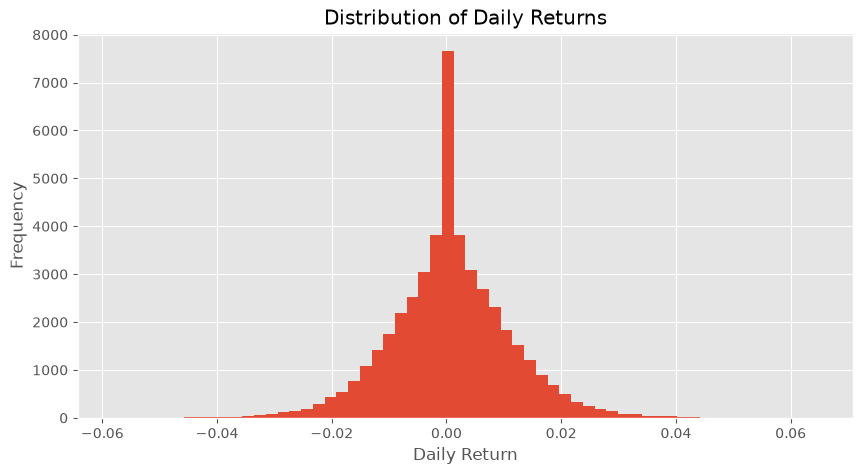

In [8]:
plt.figure(figsize=(10, 5))

nav["daily_return"].dropna().hist(bins=60)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

In [9]:
from pandas.tseries.offsets import DateOffset

def calculate_cagr(group, years):
    """
    Calculate CAGR for a given number of years.
    Returns NaN if insufficient history.
    """
    group = group.sort_values("date")

    end_date = group["date"].max()
    start_date = end_date - DateOffset(years=years)

    history = group[group["date"] >= start_date]

    if len(history) < 2:
        return np.nan

    start_nav = history.iloc[0]["nav"]
    end_nav = history.iloc[-1]["nav"]

    return (end_nav / start_nav) ** (1 / years) - 1

In [10]:
cagr_results = []

for code, group in nav.groupby("amfi_code"):
    cagr_results.append({
        "amfi_code": code,
        "CAGR_1Y": calculate_cagr(group, 1),
        "CAGR_3Y": calculate_cagr(group, 3),
        "CAGR_5Y": calculate_cagr(group, 5)
    })

cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,0.023168
1,100025,0.037050,0.039164,0.039127
2,100033,0.532324,0.324425,0.260741
3,101206,0.479241,0.289677,0.204427
4,101207,-0.239860,-0.041524,0.069533


In [11]:
display_df = cagr_df.copy()

display_df["CAGR_1Y"] *= 100
display_df["CAGR_3Y"] *= 100
display_df["CAGR_5Y"] *= 100

display_df.round(2).head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.22,1.29,2.32
1,100025,3.70,3.92,3.91
2,100033,53.23,32.44,26.07
3,101206,47.92,28.97,20.44
4,101207,-23.99,-4.15,6.95


In [12]:
cagr_df.to_csv("../reports/cagr_comparison.csv", index=False)

print("CAGR comparison saved successfully!")

CAGR comparison saved successfully!


In [13]:
# Annual risk-free rate (6.5%)
rf = 0.065

def sharpe_ratio(returns):
    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    annual_return = returns.mean() * 252
    annual_volatility = returns.std() * np.sqrt(252)

    return (annual_return - rf) / annual_volatility

In [14]:
sharpe_results = []

for code, group in nav.groupby("amfi_code"):
    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe_ratio(group["daily_return"])
    })

sharpe_df = pd.DataFrame(sharpe_results)

sharpe_df = sharpe_df.sort_values(
    by="Sharpe_Ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,Sharpe_Ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [15]:
sharpe_df.to_csv("../reports/sharpe_ratio.csv", index=False)

print("Sharpe Ratio saved successfully!")

Sharpe Ratio saved successfully!


In [16]:
def sortino_ratio(returns):
    returns = returns.dropna()

    if len(returns) < 2:
        return np.nan

    downside = returns[returns < 0]

    if len(downside) == 0:
        return np.nan

    downside_std = downside.std() * np.sqrt(252)

    annual_return = returns.mean() * 252

    return (annual_return - rf) / downside_std

In [17]:
sortino_results = []

for code, group in nav.groupby("amfi_code"):
    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino_ratio(group["daily_return"])
    })

sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    by="Sortino_Ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353
38,149323,1.875101
9,118632,1.850133
2,100033,1.829134
24,120504,1.805294
3,101206,1.799563


In [18]:
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

print("Sortino Ratio saved successfully!")

Sortino Ratio saved successfully!


In [19]:
print(benchmark.head())

print(benchmark.columns)

print(benchmark.info())

         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15
Index(['date', 'index_name', 'close_value'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB
None


In [20]:
# Convert benchmark date
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Select only NIFTY100
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

# Calculate benchmark daily returns
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [21]:
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    fund = group[["date", "daily_return"]].dropna()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    result = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = result.intercept * 252
    beta = result.slope

    alpha_beta.append({
        "amfi_code": code,
        "Alpha": alpha,
        "Beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta)

alpha_beta_df.head()

,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [22]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha & Beta saved successfully!")

Alpha & Beta saved successfully!


In [23]:
print(benchmark["index_name"].unique())

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str


In [24]:
def max_drawdown(nav_series):
    running_max = nav_series.cummax()
    drawdown = (nav_series / running_max) - 1

    min_drawdown = drawdown.min()

    end_idx = drawdown.idxmin()
    start_idx = nav_series.loc[:end_idx].idxmax()

    return min_drawdown, start_idx, end_idx

In [25]:
drawdown_results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").reset_index(drop=True)

    mdd, start_idx, end_idx = max_drawdown(group["nav"])

    drawdown_results.append({
        "amfi_code": code,
        "Max_Drawdown": mdd,
        "Peak_Date": group.loc[start_idx, "date"],
        "Trough_Date": group.loc[end_idx, "date"]
    })

drawdown_df = pd.DataFrame(drawdown_results)

drawdown_df.head()

,amfi_code,Max_Drawdown,Peak_Date,Trough_Date
0,100016,-0.247344,2022-03-30,2022-09-15
1,100025,-0.043083,2023-05-23,2023-07-28
2,100033,-0.162172,2022-03-11,2022-05-12
3,101206,-0.112916,2023-04-24,2023-07-05
4,101207,-0.354469,2024-11-21,2026-05-11


In [26]:
scorecard = cagr_df.merge(sharpe_df, on="amfi_code")

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code", "Max_Drawdown"]],
    on="amfi_code"
)

In [27]:
scorecard["Return_Rank"] = scorecard["CAGR_3Y"].rank(
    ascending=False
)

scorecard["Sharpe_Rank"] = scorecard["Sharpe_Ratio"].rank(
    ascending=False
)

scorecard["Alpha_Rank"] = scorecard["Alpha"].rank(
    ascending=False
)

scorecard["Drawdown_Rank"] = scorecard["Max_Drawdown"].rank(
    ascending=False
)


In [28]:
scorecard["Fund_Score"] = (
    0.40 * scorecard["Return_Rank"] +
    0.35 * scorecard["Sharpe_Rank"] +
    0.25 * scorecard["Alpha_Rank"]
)

In [29]:
scorecard["Fund_Score"] = (
    100
    * (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"]
    )
    / (
        scorecard["Fund_Score"].max()
        - scorecard["Fund_Score"].min()
    )
)

scorecard = scorecard.sort_values(
    "Fund_Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y,Sharpe_Ratio,Alpha,Beta,Max_Drawdown,Return_Rank,Sharpe_Rank,Alpha_Rank,Drawdown_Rank,Fund_Score
34,148567,0.203607,0.340009,0.267993,1.448291,0.269838,0.023684,-0.112657,2.0,1.0,7.0,8.0,100.000000
25,120505,0.296047,0.317775,0.283768,1.180101,0.292636,0.000549,-0.181885,5.0,5.0,3.0,25.0,95.362319
30,120843,0.266571,0.295828,0.267425,1.306744,0.273305,-0.022830,-0.129740,7.0,2.0,5.0,13.0,94.637681
36,148569,0.397518,0.291789,0.276299,1.234930,0.282704,0.018134,-0.163967,8.0,3.0,4.0,21.0,93.188406
2,100033,0.532324,0.324425,0.260741,1.093699,0.271954,0.005104,-0.162172,4.0,7.0,6.0,20.0,92.318841
19,119551,0.604373,0.304565,0.223849,1.208267,0.232010,-0.031751,-0.150124,6.0,4.0,10.0,17.0,90.144928
16,119094,0.222611,0.351118,0.244453,0.998231,0.260767,-0.066265,-0.209609,1.0,11.0,9.0,28.0,89.565217
24,120504,0.130643,0.324874,0.202340,1.026524,0.211948,0.016232,-0.125883,3.0,10.0,13.0,12.0,85.362319
38,149323,0.214812,0.268700,0.256118,1.132122,0.265986,-0.002523,-0.172481,11.0,6.0,8.0,22.0,83.768116
39,149324,0.651387,0.270004,0.279174,0.949796,0.300579,0.011455,-0.311719,10.0,13.0,2.0,37.0,82.173913


In [30]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [31]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard saved successfully!")

Fund Scorecard saved successfully!


In [32]:
top5 = scorecard.head(5)["amfi_code"].tolist()

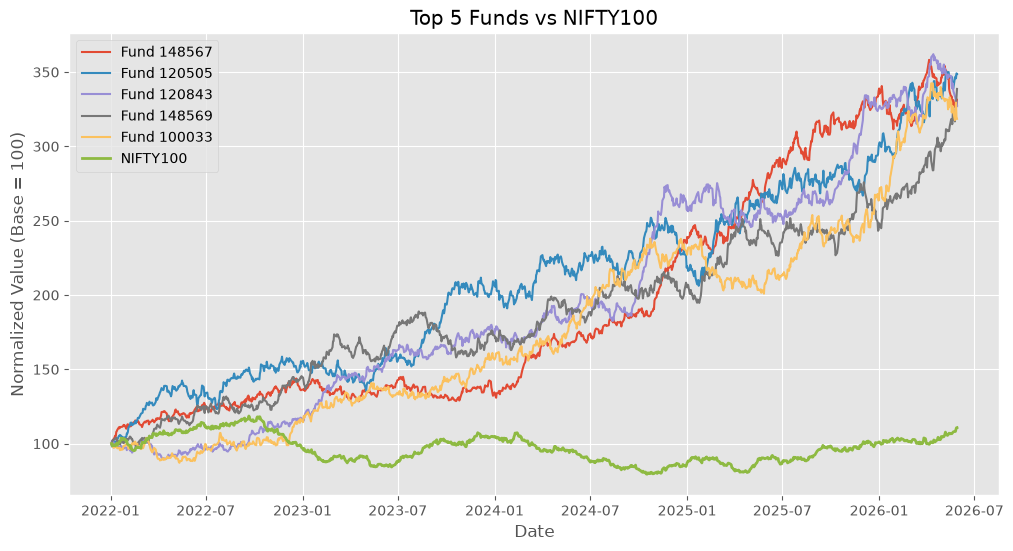

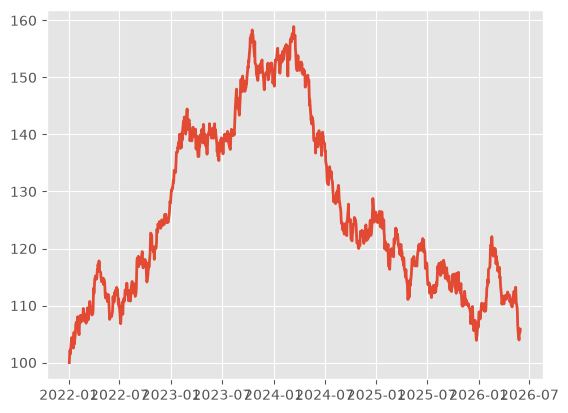

In [37]:
plt.figure(figsize=(12, 6))

for code in top5:
    temp = nav[nav["amfi_code"] == code].copy()
    temp = temp.sort_values("date")

    # Normalize NAV to start at 100
    temp["normalized"] = (
        temp["nav"] / temp["nav"].iloc[0]
    ) * 100

    plt.plot(
        temp["date"],
        temp["normalized"],
        label=f"Fund {code}"
    )

# Normalize NIFTY100 to start at 100
benchmark_plot = nifty100.copy()
benchmark_plot["normalized"] = (
    benchmark_plot["close_value"] / benchmark_plot["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark_plot["date"],
    benchmark_plot["normalized"],
    linewidth=2,
    label="NIFTY100"
)

plt.title("Top 5 Funds vs NIFTY100")
plt.xlabel("Date")
plt.ylabel("Normalized Value (Base = 100)")
plt.legend()
plt.grid(True)

plt.savefig("../reports/benchmark_comparison.png", dpi=300)

plt.show()
benchmark50 = nifty50.copy()

benchmark50["normalized"] = (
    benchmark50["close_value"] /
    benchmark50["close_value"].iloc[0]
) * 100

plt.plot(
    benchmark50["date"],
    benchmark50["normalized"],
    linewidth=2,
    label="NIFTY50"
)

In [34]:
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].copy()

nifty50 = nifty50.sort_values("date")

nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

In [35]:
tracking_error_results = []

for code in top5:

    fund = nav[nav["amfi_code"] == code][["date","daily_return"]]

    merged = pd.merge(
        fund,
        nifty100[["date","benchmark_return"]],
        on="date"
    ).dropna()

    tracking_error = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std() * np.sqrt(252)
    )

    tracking_error_results.append({
        "amfi_code": code,
        "Tracking_Error": tracking_error
    })

tracking_error_df = pd.DataFrame(tracking_error_results)

tracking_error_df

,amfi_code,Tracking_Error
0,148567,0.189664
1,120505,0.231968
2,120843,0.206425
3,148569,0.217365
4,100033,0.228699


In [36]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("Tracking Error saved successfully!")

Tracking Error saved successfully!
